In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('Iris.csv')

In [3]:
df=df.iloc[:,1:]

In [4]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
le=LabelEncoder()
df['Species']=le.fit_transform(df.iloc[:,-1])

In [7]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [8]:
df=df[df["Species"]!=0][['SepalWidthCm','PetalLengthCm','Species']]

In [9]:
df

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1
...,...,...,...
145,3.0,5.2,2
146,2.5,5.0,2
147,3.0,5.2,2
148,3.4,5.4,2


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

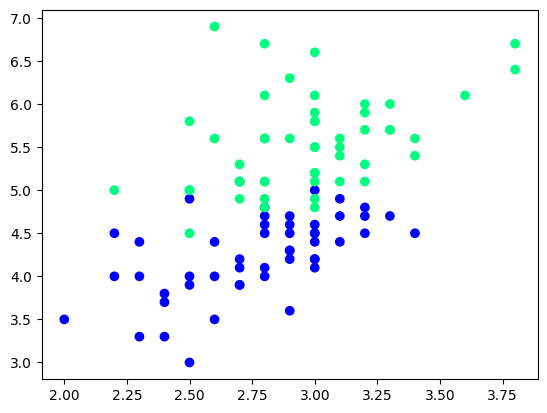

In [11]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],cmap='winter',c=df['Species'])

main working start from here taking the subset of the data

In [12]:
df.shape

(100, 3)

In [13]:
# taking only 10 rows for training
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)     # validation
df_test=df.iloc[80:,:].sample(5)

In [14]:
X_test=df_val.iloc[:,0:2].values
y_test=df_val.iloc[:,-1].values

# case 1) bagging

In [16]:
# data for tree 1
df_bag=df_train.sample(8,replace=True)  # true means row can repeat
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
144,3.3,5.7,2
55,2.8,4.5,1
118,2.6,6.9,2
50,3.2,4.7,1
124,3.3,5.7,2
144,3.3,5.7,2
122,2.8,6.7,2


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [19]:

def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    


In [18]:
dt_bag1 = DecisionTreeClassifier()

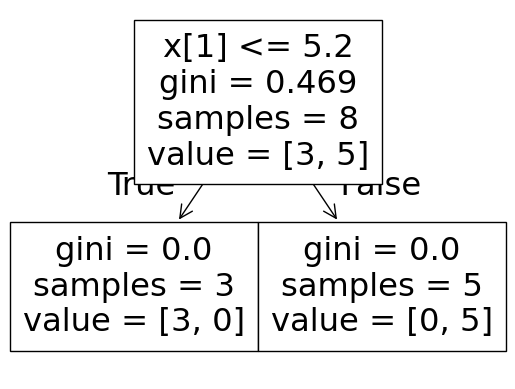

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


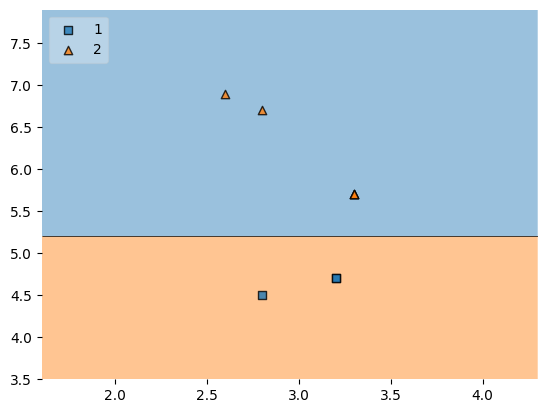

In [20]:
evaluate(dt_bag1,X,y)

# predict

In [21]:
df_test

,SepalWidthCm,PetalLengthCm,Species
88,3.0,4.1,1
77,3.0,5.0,1
106,2.5,4.5,2
146,2.5,5.0,2
90,2.6,4.4,1


In [22]:
import numpy as np

In [23]:
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
110,3.2,5.1,2
124,3.3,5.7,2
144,3.3,5.7,2
82,2.7,3.9,1
118,2.6,6.9,2
52,3.1,4.9,1
50,3.2,4.7,1
122,2.8,6.7,2


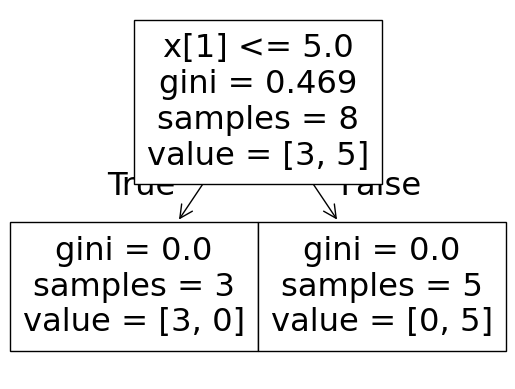

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


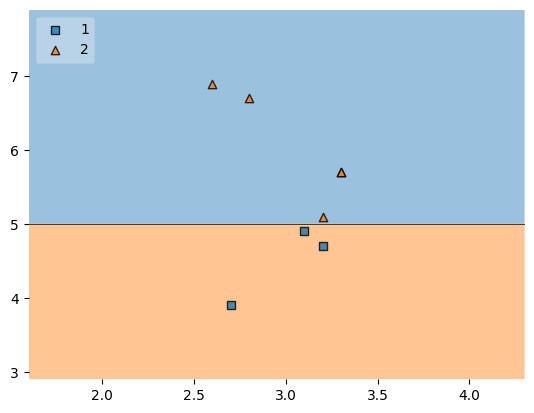

In [24]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [25]:
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
142,2.7,5.1,2
142,2.7,5.1,2
52,3.1,4.9,1
124,3.3,5.7,2
110,3.2,5.1,2
110,3.2,5.1,2
118,2.6,6.9,2
144,3.3,5.7,2


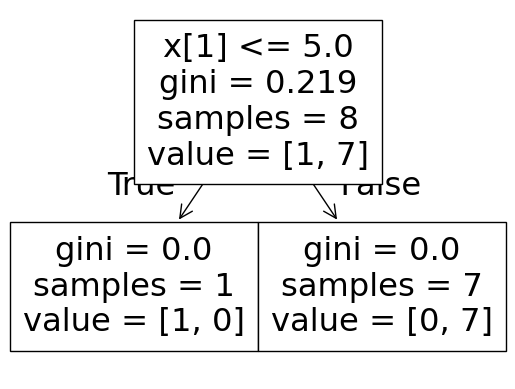

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


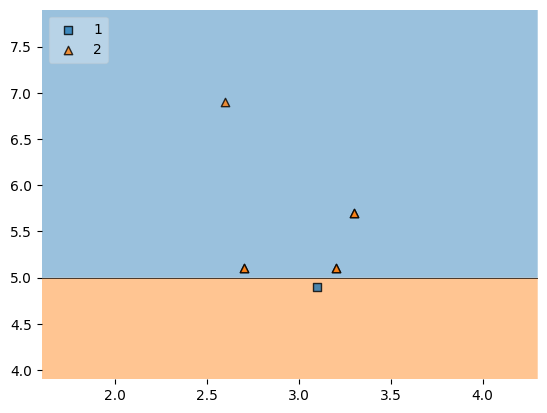

In [26]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [30]:
df_test

,SepalWidthCm,PetalLengthCm,Species
88,3.0,4.1,1
77,3.0,5.0,1
106,2.5,4.5,2
146,2.5,5.0,2
90,2.6,4.4,1


In [27]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# pasting

In [31]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
82,2.7,3.9,1
52,3.1,4.9,1
118,2.6,6.9,2
50,3.2,4.7,1
55,2.8,4.5,1
142,2.7,5.1,2
144,3.3,5.7,2
110,3.2,5.1,2
122,2.8,6.7,2
124,3.3,5.7,2


In [32]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
55,2.8,4.5,1
50,3.2,4.7,1
110,3.2,5.1,2
142,2.7,5.1,2
52,3.1,4.9,1
144,3.3,5.7,2
124,3.3,5.7,2
122,2.8,6.7,2


# random subspaces

In [33]:
df1 = pd.read_csv('Iris.csv')
df1 = df1.sample(10)

In [34]:

df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
18,19,5.7,3.8,1.7,0.3,Iris-setosa
60,61,5.0,2.0,3.5,1.0,Iris-versicolor
92,93,5.8,2.6,4.0,1.2,Iris-versicolor
19,20,5.1,3.8,1.5,0.3,Iris-setosa
71,72,6.1,2.8,4.0,1.3,Iris-versicolor
61,62,5.9,3.0,4.2,1.5,Iris-versicolor
23,24,5.1,3.3,1.7,0.5,Iris-setosa
142,143,5.8,2.7,5.1,1.9,Iris-virginica
48,49,5.3,3.7,1.5,0.2,Iris-setosa
126,127,6.2,2.8,4.8,1.8,Iris-virginica


In [35]:
df1.sample(2,replace=True,axis=1)

,PetalWidthCm,Species
18,0.3,Iris-setosa
60,1.0,Iris-versicolor
92,1.2,Iris-versicolor
19,0.3,Iris-setosa
71,1.3,Iris-versicolor
61,1.5,Iris-versicolor
23,0.5,Iris-setosa
142,1.9,Iris-virginica
48,0.2,Iris-setosa
126,1.8,Iris-virginica


# random patches

In [36]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
18,19,5.7,3.8,1.7,0.3,Iris-setosa
60,61,5.0,2.0,3.5,1.0,Iris-versicolor
92,93,5.8,2.6,4.0,1.2,Iris-versicolor
19,20,5.1,3.8,1.5,0.3,Iris-setosa
71,72,6.1,2.8,4.0,1.3,Iris-versicolor
61,62,5.9,3.0,4.2,1.5,Iris-versicolor
23,24,5.1,3.3,1.7,0.5,Iris-setosa
142,143,5.8,2.7,5.1,1.9,Iris-virginica
48,49,5.3,3.7,1.5,0.2,Iris-setosa
126,127,6.2,2.8,4.8,1.8,Iris-virginica


In [37]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,SepalLengthCm,PetalLengthCm
92,5.8,4.0
48,5.3,1.5
60,5.0,3.5
92,5.8,4.0
23,5.1,1.7
19,5.1,1.5
71,6.1,4.0
18,5.7,1.7
